In [1]:
# import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor


In [2]:
# Load data
DF_PATH = "job_salary_prediction_dataset.csv"
df = pd.read_csv(DF_PATH)


Shape: (250000, 10)

Missing values:
 job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

Salary summary:
 count    250000.000000
mean     145718.080524
std       37407.952729
min       31867.000000
25%      119358.000000
50%      143453.000000
75%      169492.000000
max      333046.000000
Name: salary, dtype: float64


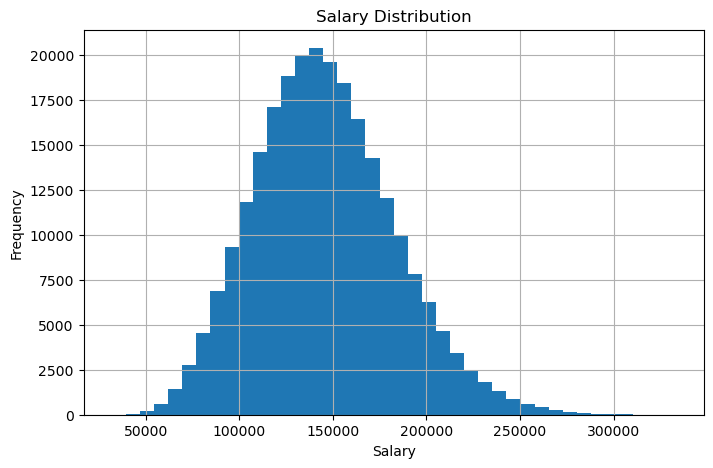

In [3]:
# EDA
# -----------------------------
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nSalary summary:\n", df["salary"].describe())

plt.figure(figsize=(8, 5))
df["salary"].hist(bins=40)
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.show()

In [4]:
# Feature engineering
# -----------------------------

def exp_bucket(x):
    if x <= 2:
        return "entry"
    elif x <= 5:
        return "junior"
    elif x <= 10:
        return "mid"
    elif x <= 15:
        return "senior"
    return "lead"


df["experience_bucket"] = df["experience_years"].apply(exp_bucket)
df["skill_strength"] = df["skills_count"] + (df["certifications"] * 2)
df["exp_skill_interaction"] = df["experience_years"] * df["skills_count"]

education_map = {
    "High School": 0,
    "Diploma": 1,
    "Bachelor": 2,
    "Master": 3,
    "PhD": 4,
}

company_map = {
    "Startup": 0,
    "Small": 1,
    "Medium": 2,
    "Large": 3,
    "Enterprise": 4,
}

remote_map = {
    "No": 0,
    "Hybrid": 1,
    "Yes": 2,
}




In [5]:
# temporary encoded columns for interaction features
if "education_level" in df.columns:
    df["education_level_encoded"] = df["education_level"].map(education_map)
if "company_size" in df.columns:
    df["company_size_encoded"] = df["company_size"].map(company_map)
if "remote_work" in df.columns:
    df["remote_encoded"] = df["remote_work"].map(remote_map)


In [6]:
# interaction features
if "company_size_encoded" in df.columns:
    df["experience_company"] = df["experience_years"] * df["company_size_encoded"]
if "education_level_encoded" in df.columns:
    df["experience_education"] = df["experience_years"] * df["education_level_encoded"]


In [7]:
# Split
# -----------------------------
X = df.drop("salary", axis=1)
y = df["salary"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

In [8]:
# Preprocessing
# -----------------------------
ordinal_features = ["education_level", "company_size", "remote_work"]
ordinal_categories = [
    ["High School", "Diploma", "Bachelor", "Master", "PhD"],
    ["Startup", "Small", "Medium", "Large", "Enterprise"],
    ["No", "Hybrid", "Yes"],
]

onehot_features = [
    "job_title",
    "industry",
    "location",
    "experience_bucket",
]

numeric_features = [
    col for col in X.columns
    if col not in ordinal_features + onehot_features
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "ord",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OrdinalEncoder(categories=ordinal_categories)),
            ]),
            ordinal_features,
        ),
        (
            "onehot",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore")),
            ]),
            onehot_features,
        ),
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
            ]),
            numeric_features,
        ),
    ]
)



In [9]:
# Model (Version 2)
# -----------------------------
model = XGBRegressor(
    n_estimators=250,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    n_jobs=-1,
)


pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model),
])

pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ord',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder(categories=[['High '
                                                                                               'School',
                                                                                               'Diploma',
                                                                                               'Bachelor',
                                                                                               'Master',
                                                                                               'PhD'],
                                                                                              ['Startup',
                                                                                               'Small',
                                                                                               'Medium',
                                                                                               'Large',
                                                                                               'Enterprise'],
                                                                                              ['No',
                                                                                               'Hybrid',
                                                                                               'Yes']]))]),
                                                  ['education_level',
                                                   'company_size',
                                                   'remote_w...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=6, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=250, n_jobs=-1,
                              num_parallel_tree=None, ...))])

In [10]:
# Evaluation
# -----------------------------
preds = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print("\nModel evaluation")
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²:", round(r2, 4))



Model evaluation
MAE: 4196.76
RMSE: 5262.31
R²: 0.9801


In [11]:
# Error analysis
results = pd.DataFrame({
    "actual": y_test,
    "predicted": preds,
})
results["error"] = results["actual"] - results["predicted"]
results["abs_error"] = results["error"].abs()

print("\nTop 10 largest errors")
print(results.sort_values("abs_error", ascending=False).head(10))



Top 10 largest errors
        actual      predicted         error     abs_error
8576     95178  116302.437500 -21124.437500  21124.437500
63693    93486  114442.937500 -20956.937500  20956.937500
62450   215004  194053.171875  20950.828125  20950.828125
12601   293673  273086.187500  20586.812500  20586.812500
231139  228706  208240.796875  20465.203125  20465.203125
34494   133355  113032.242188  20322.757812  20322.757812
131698  194188  214390.109375 -20202.109375  20202.109375
118823  173210  153156.671875  20053.328125  20053.328125
249365  165506  145611.687500  19894.312500  19894.312500
19300   180045  160180.125000  19864.875000  19864.875000


In [13]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("CV R²:", scores)
print("Mean CV R²:", scores.mean())

CV R²: [0.98015362 0.98005587 0.98018014 0.98022801 0.980057  ]
Mean CV R²: 0.980134928226471


In [ ]:
# Save the model
import joblib
joblib.dump(pipeline,'excellent')